In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        import warnings
warnings.filterwarnings("ignore")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-media-user-activity-dataset/instagram_usage_lifestyle.csv


**SUMMARY OF FINDINGS# **

* Based on the analysis of total activity across the dataset, the users with the highest activity tend to fall into specific demographic and lifestyle categories.Most active users are aged 26–50, predominantly female, and primarily located in urban areas of the United States. They generally have a middle income level, are full-time employed, and are single without children. In terms of lifestyle, these users typically engage in moderate exercise (0–10 hours per week), sleep around 7 hours per night, and maintain an average diet quality. They do not smoke, consume alcohol rarely, and experience low perceived stress (0–10). Weekly work hours for the most active users are usually in the 26–50 hours range.
* The users with the lowest total activity tend to fall into very different categories. They are generally older adults (76–99 years), often prefer not to disclose their gender, and are concentrated in countries like Japan or rural areas. Many are in the high-income bracket, retired, widowed, or have children. Lifestyle-wise, these users tend to engage in very little or no exercise, have extreme sleep patterns (very low or very high hours), and poorer diet quality. They are more likely to smoke, drink alcohol daily, and report high perceived stress. Their weekly work hours are minimal (or zero if retired)
* Linear Regression with all varaibles shows Adjusted R square around 95% with significant f stat.
* Linear Regression with chosen variables based on relevance has lower Adjusted R square but *lower* chance of multicolinearity. 
.

****SUMMARY ABOUT UNCLEANED DATASET****

In [2]:
df=pd.read_csv("/kaggle/input/social-media-user-activity-dataset/instagram_usage_lifestyle.csv")
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

**CLEANING AND EDA**

In [3]:
cols_to_combine = [
    'posts_created_per_week',
    'reels_watched_per_day',
    'stories_viewed_per_day',
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day'
]

df['total_activity'] = df[cols_to_combine].sum(axis=1)
df = df.drop(columns=cols_to_combine)


In [4]:
print('Dropped 6 columns')
cleaned=df.drop(columns=['app_name','biometric_login_used','linked_accounts_count', 'last_login_date','account_creation_year','two_factor_auth_enabled'])
cleaned

Dropped 6 columns


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,following_count,uses_premium_features,notification_response_rate,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,subscription_status,user_engagement_score,total_activity
0,1,51,Female,India,Rural,High,Retired,Bachelor’s,Single,No,...,647,No,0.34,5.0,Mixed,Tech,Private,Free,7.83,134
1,2,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,...,3511,No,0.56,14.8,Photos,Fashion,Public,Free,1.43,257
2,3,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,...,6761,No,0.73,5.0,Mixed,Other,Public,Free,9.67,122
3,4,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,...,1193,No,0.73,25.9,Stories,Tech,Private,Free,0.94,619
4,5,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,...,1072,Yes,0.65,13.1,Videos,Food,Public,Free,1.03,489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,61,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,No,...,1012,No,0.48,15.8,Videos,Other,Friends only,Free,0.97,503
1547892,1547893,42,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,No,...,1348,No,0.14,38.0,Photos,Art,Private,Premium,1.32,269
1547893,1547894,32,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,No,...,1891,No,0.99,31.8,Live,Other,Private,Free,1.01,440
1547894,1547895,14,Female,Other,Urban,Low,Student,Bachelor’s,Single,No,...,4775,No,0.92,23.6,Live,Tech,Private,Free,1.11,792


In [5]:
import pandas as pd

cleaned1=cleaned.copy()


bins_dict = {
    'age': [0, 25, 50, 75, 99],
    'exercise_hours_per_week': [0, 10, 20, 30, 40],
    'perceived_stress_score': [0, 10, 20, 30, 40],
    'self_reported_happiness': [0, 2.5, 5, 7.5, 10],
    'daily_steps_count': [0, 2500, 5000, 7500, 10000],
    'weekly_work_hours': [0, 25, 50, 75, 100]
}

labels_dict = {
    'age': ['0-25', '26-50', '51-75', '76-99'],
    'exercise_hours_per_week': ['0-10', '11-20', '21-30', '31-40'],
    'perceived_stress_score': ['0-10', '11-20', '21-30', '31-40'],
    'self_reported_happiness': ['0-2.5', '2.6-5', '5.1-7.5', '7.6-10'],
    'daily_steps_count': ['0-2500', '2501-5000', '5001-7500', '7501-10000'],
    'weekly_work_hours': ['0-25', '26-50', '51-75', '76-100']
}

for col in bins_dict.keys():
    cleaned1[col] = pd.cut(cleaned1[col],
                           bins=bins_dict[col],
                           labels=labels_dict[col],
                           include_lowest=True)

cleaned1.head()


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,following_count,uses_premium_features,notification_response_rate,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,subscription_status,user_engagement_score,total_activity
0,1,51-75,Female,India,Rural,High,Retired,Bachelor’s,Single,No,...,647,No,0.34,5.0,Mixed,Tech,Private,Free,7.83,134
1,2,51-75,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,...,3511,No,0.56,14.8,Photos,Fashion,Public,Free,1.43,257
2,3,26-50,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,...,6761,No,0.73,5.0,Mixed,Other,Public,Free,9.67,122
3,4,26-50,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,...,1193,No,0.73,25.9,Stories,Tech,Private,Free,0.94,619
4,5,51-75,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,...,1072,Yes,0.65,13.1,Videos,Food,Public,Free,1.03,489


In [6]:
from colorama import Fore, Style
import pandas as pd

columns_to_analyze = [
    'age', 'gender', 'country', 'urban_rural',
    'income_level', 'employment_status', 'education_level',
    'relationship_status', 'has_children', 'exercise_hours_per_week',
    'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
    'perceived_stress_score', 'self_reported_happiness', 
    'daily_steps_count', 'weekly_work_hours'
]

for col in columns_to_analyze:
    print(Fore.BLUE + f"\n=== {col.upper()} VS TOTAL ACTIVITY ===" + Style.RESET_ALL)
    

    grouped = cleaned1.groupby(col)['total_activity'].agg(['count', 'mean', 'max', 'min'])
    
    grouped_sorted = grouped.sort_values(by='count', ascending=False)
    
    print(grouped_sorted)


=== AGE VS TOTAL ACTIVITY ===
        count        mean     max    min
age                                     
26-50  730927  505.524890  1069.0   94.0
51-75  437182  440.877323  1023.0   95.0
0-25   379787  620.614242  1087.0  171.0
76-99       0         NaN     NaN    NaN

=== GENDER VS TOTAL ACTIVITY ===
                    count        mean   max  min
gender                                          
Male               743169  515.573362  1087   96
Female             742847  515.523032  1069   94
Non-binary          46196  515.514763  1054   98
Prefer not to say   15684  511.288192  1019   99

=== COUNTRY VS TOTAL ACTIVITY ===
                 count        mean   max  min
country                                      
United States   386829  515.054644  1069   96
India           278342  516.160831  1087   96
Brazil          186258  515.572131  1059   97
Other           154572  515.578229  1037  101
United Kingdom  123411  515.685749  1050   95
Canada          108584  515.055027  10

In [7]:

for col in columns_to_analyze:
    print(Fore.BLUE + f"\n=== {col.upper()} VS TOTAL ACTIVITY ===" + Style.RESET_ALL)
    

    grouped = cleaned1.groupby(col)['total_activity'].agg(['count', 'mean', 'max', 'min'])
    
   
    highest = grouped['count'].idxmax(), grouped['count'].max()
    lowest = grouped['count'].idxmin(), grouped['count'].min()
    
    print(Fore.GREEN + f"Highest count: {highest[0]} -> {highest[1]}" + Style.RESET_ALL)
    print(Fore.RED + f"Lowest count: {lowest[0]} -> {lowest[1]}" + Style.RESET_ALL)


=== AGE VS TOTAL ACTIVITY ===
Highest count: 26-50 -> 730927
Lowest count: 76-99 -> 0

=== GENDER VS TOTAL ACTIVITY ===
Highest count: Male -> 743169
Lowest count: Prefer not to say -> 15684

=== COUNTRY VS TOTAL ACTIVITY ===
Highest count: United States -> 386829
Lowest count: Japan -> 61999

=== URBAN_RURAL VS TOTAL ACTIVITY ===
Highest count: Urban -> 850754
Lowest count: Rural -> 232537

=== INCOME_LEVEL VS TOTAL ACTIVITY ===
Highest count: Middle -> 465037
Lowest count: High -> 154561

=== EMPLOYMENT_STATUS VS TOTAL ACTIVITY ===
Highest count: Full-time employed -> 695383
Lowest count: Retired -> 46614

=== EDUCATION_LEVEL VS TOTAL ACTIVITY ===
Highest count: Bachelor’s -> 541083
Lowest count: PhD -> 46622

=== RELATIONSHIP_STATUS VS TOTAL ACTIVITY ===
Highest count: Single -> 619236
Lowest count: Widowed -> 30838

=== HAS_CHILDREN VS TOTAL ACTIVITY ===
Highest count: No -> 1115158
Lowest count: Yes -> 432738

=== EXERCISE_HOURS_PER_WEEK VS TOTAL ACTIVITY ===
Highest count: 0-10 

In [8]:
df.drop_duplicates()
nandop=df.dropna()

print('Previous NaN', len(df))
print('Current N NaN', len(nandop))
print('Dropped NaN rows', (len(df)) - len(nandop))
print("Double check if there are any NaN:", (df.isna().any().any()))


Previous NaN 1547896
Current N NaN 1547896
Dropped NaN rows 0
Double check if there are any NaN: False


**DUMMY VARIABLES**

In [9]:
df_dummies = pd.get_dummies(cleaned, columns=['gender', 'country', 'urban_rural', 'income_level', 'employment_status', 'education_level', 'relationship_status', 'has_children', 'diet_quality', 'smoking', 'alcohol_frequency', 'uses_premium_features', 'content_type_preference', 'preferred_content_theme', 'privacy_setting_level', 'subscription_status'], drop_first=True)
print(list(df_dummies))
df_dummies

['user_id', 'age', 'exercise_hours_per_week', 'sleep_hours_per_night', 'perceived_stress_score', 'self_reported_happiness', 'body_mass_index', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'daily_steps_count', 'weekly_work_hours', 'hobbies_count', 'social_events_per_month', 'books_read_per_year', 'volunteer_hours_per_month', 'travel_frequency_per_year', 'daily_active_minutes_instagram', 'sessions_per_day', 'ads_clicked_per_day', 'time_on_feed_per_day', 'time_on_explore_per_day', 'time_on_messages_per_day', 'time_on_reels_per_day', 'followers_count', 'following_count', 'notification_response_rate', 'average_session_length_minutes', 'user_engagement_score', 'total_activity', 'gender_Male', 'gender_Non-binary', 'gender_Prefer not to say', 'country_Brazil', 'country_Canada', 'country_Germany', 'country_India', 'country_Japan', 'country_Other', 'country_South Korea', 'country_United Kingdom', 'country_United States', 'urban_rural_Suburban', 'urban_rural_Urban', 'income_level_Low', 

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,preferred_content_theme_Fitness,preferred_content_theme_Food,preferred_content_theme_Music,preferred_content_theme_Other,preferred_content_theme_Tech,preferred_content_theme_Travel,privacy_setting_level_Private,privacy_setting_level_Public,subscription_status_Free,subscription_status_Premium
0,1,51,7.2,7.7,3,8,20.8,148,86,8107,...,False,False,False,False,True,False,True,False,True,False
1,2,64,10.9,8.6,1,1,23.5,133,84,8059,...,False,False,False,False,False,False,False,True,True,False
2,3,41,5.0,6.7,4,10,28.6,135,88,7872,...,False,False,False,True,False,False,False,True,True,False
3,4,27,10.6,6.5,18,1,22.5,105,73,7801,...,False,False,False,False,True,False,True,False,True,False
4,5,55,7.7,6.8,19,1,28.1,146,90,8005,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,61,4.0,8.5,25,7,27.4,106,96,7863,...,False,False,False,True,False,False,False,False,True,False
1547892,1547893,42,3.1,6.1,8,7,24.2,95,71,7978,...,False,False,False,False,False,False,True,False,False,True
1547893,1547894,32,4.4,6.4,4,1,20.8,97,65,7898,...,False,False,False,True,False,False,True,False,True,False
1547894,1547895,14,14.4,6.5,28,7,31.1,97,96,7947,...,False,False,False,False,True,False,True,False,True,False


**CORRELATION HEATMAP**

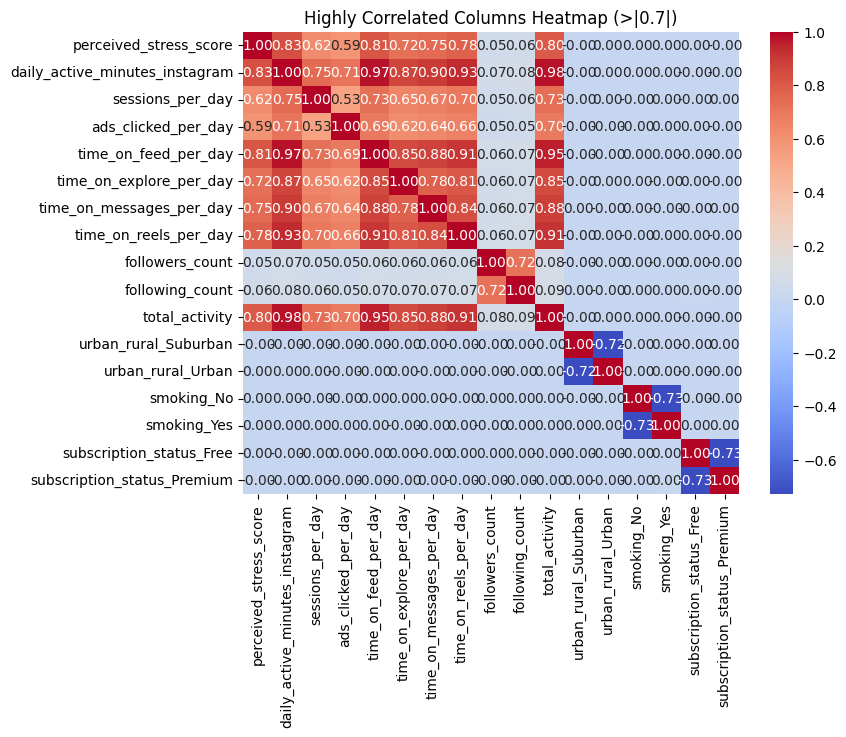

In [10]:
corr = df_dummies.corr()
threshold = 0.7  
high_corr = corr.abs() > threshold

cols_to_keep = [col for col in corr.columns if (high_corr[col].sum() > 1)]
filtered_corr = corr.loc[cols_to_keep, cols_to_keep]
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)
plt.title("Highly Correlated Columns Heatmap (>|0.7|)")
plt.show()


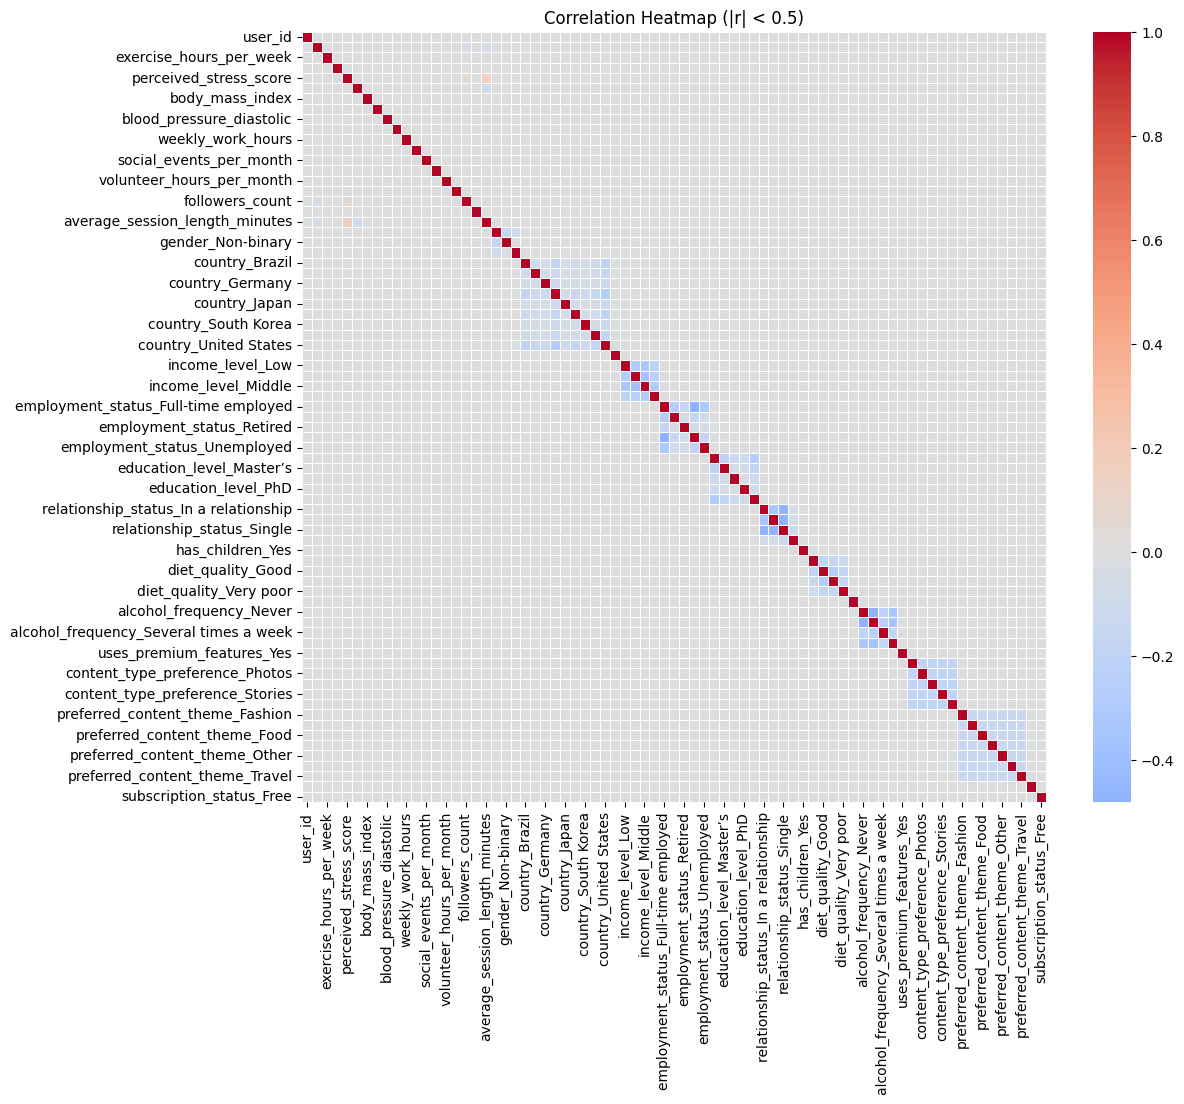

['user_id',
 'age',
 'exercise_hours_per_week',
 'sleep_hours_per_night',
 'perceived_stress_score',
 'self_reported_happiness',
 'body_mass_index',
 'blood_pressure_systolic',
 'blood_pressure_diastolic',
 'daily_steps_count',
 'weekly_work_hours',
 'hobbies_count',
 'social_events_per_month',
 'books_read_per_year',
 'volunteer_hours_per_month',
 'travel_frequency_per_year',
 'followers_count',
 'notification_response_rate',
 'average_session_length_minutes',
 'gender_Male',
 'gender_Non-binary',
 'gender_Prefer not to say',
 'country_Brazil',
 'country_Canada',
 'country_Germany',
 'country_India',
 'country_Japan',
 'country_Other',
 'country_South Korea',
 'country_United Kingdom',
 'country_United States',
 'urban_rural_Suburban',
 'income_level_Low',
 'income_level_Lower-middle',
 'income_level_Middle',
 'income_level_Upper-middle',
 'employment_status_Full-time employed',
 'employment_status_Part-time',
 'employment_status_Retired',
 'employment_status_Student',
 'employment_st

In [11]:
corr2 = df_dummies.corr()
import numpy as np

threshold = 0.5

upper = corr2.abs().where(
    np.triu(np.ones(corr2.shape), k=1).astype(bool)
)
cols_to_drop = [
    column for column in upper.columns 
    if any(upper[column] >= threshold)
]

df_uncorrelated = df_dummies.drop(columns=cols_to_drop)

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_uncorrelated.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap (|r| < 0.5)")
plt.show()
list(df_uncorrelated)

In [12]:
df_dummies['total_activity']

0          134
1          257
2          122
3          619
4          489
          ... 
1547891    503
1547892    269
1547893    440
1547894    792
1547895    312
Name: total_activity, Length: 1547896, dtype: int64

**MODEL**

In [13]:
import statsmodels.api as sm
import numpy as np

y = df_dummies['total_activity'].copy()
X = df_dummies.drop(columns=['total_activity']).copy()


for col in X.columns:
    if X[col].dtype == 'bool':      
        X[col] = X[col].astype(int)
    elif X[col].dtype == 'object':    
        X[col] = pd.to_numeric(X[col], errors='coerce')

y = pd.to_numeric(y, errors='coerce')

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]


X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]


X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         total_activity   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 6.942e+05
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:32:21   Log-Likelihood:            -7.6442e+06
No. Observations:             1547896   AIC:                         1.529e+07
Df Residuals:                 1547807   BIC:                         1.529e+07
Df Model:                          88                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

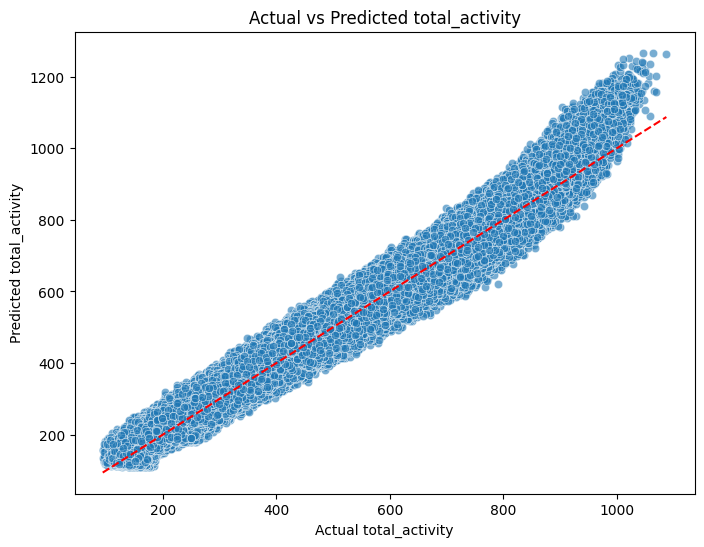

In [14]:
y_pred = model.predict(X)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # perfect fit line
plt.xlabel('Actual total_activity')
plt.ylabel('Predicted total_activity')
plt.title('Actual vs Predicted total_activity')
plt.show()

In [15]:
model.pvalues
alpha = 0.05  
significant_vars = model.pvalues[model.pvalues > alpha]
print(significant_vars)


user_id                           0.581329
exercise_hours_per_week           0.371650
sleep_hours_per_night             0.766962
body_mass_index                   0.591858
blood_pressure_systolic           0.903478
                                    ...   
preferred_content_theme_Travel    0.560512
privacy_setting_level_Private     0.757686
privacy_setting_level_Public      0.631095
subscription_status_Free          0.171167
subscription_status_Premium       0.180943
Length: 77, dtype: float64


**CHOSEN VALUES BASED ON RELEVANCE**


In [16]:
import numpy as np
import statsmodels.api as sm

cols_to_model = [
    'exercise_hours_per_week', 'sleep_hours_per_night', 'perceived_stress_score',
    'self_reported_happiness', 'weekly_work_hours', 'social_events_per_month',
    'books_read_per_year', 'gender_Male', 'gender_Non-binary', 'gender_Prefer not to say',
    'country_Brazil', 'country_Canada', 'country_Germany', 'country_India',
    'country_Japan', 'country_Other', 'country_South Korea', 'country_United Kingdom',
    'country_United States', 'urban_rural_Suburban', 'income_level_Low',
    'income_level_Lower-middle', 'income_level_Middle', 'income_level_Upper-middle',
    'employment_status_Full-time employed', 'employment_status_Part-time',
    'employment_status_Retired', 'employment_status_Student', 'employment_status_Unemployed',
    'education_level_High school', 'education_level_Master’s', 'education_level_Other',
    'education_level_PhD', 'education_level_Some college',
    'relationship_status_In a relationship', 'relationship_status_Married',
    'relationship_status_Single', 'relationship_status_Widowed', 'has_children_Yes',
    'diet_quality_Excellent', 'diet_quality_Good', 'diet_quality_Poor', 'diet_quality_Very poor',
    'smoking_No', 'smoking_Yes', 'alcohol_frequency_Never', 'alcohol_frequency_Rarely',
    'alcohol_frequency_Several times a week', 'alcohol_frequency_Weekly',
    'uses_premium_features_Yes', 'content_type_preference_Mixed',
    'content_type_preference_Photos', 'content_type_preference_Reels',
    'content_type_preference_Stories', 'content_type_preference_Videos',
    'preferred_content_theme_Fashion', 'preferred_content_theme_Fitness',
    'preferred_content_theme_Food', 'preferred_content_theme_Music',
    'preferred_content_theme_Other', 'preferred_content_theme_Tech',
    'preferred_content_theme_Travel', 'privacy_setting_level_Private',
    'privacy_setting_level_Public', 'subscription_status_Free', 'subscription_status_Premium'
]

X3 = df_dummies[cols_to_model].copy()
y3 = df_dummies['total_activity'].copy()


for col in X3.columns:
    if X3[col].dtype == 'bool':
        X3[col] = X3[col].astype(int)
    else:
        X3[col] = pd.to_numeric(X3[col], errors='coerce')

y = pd.to_numeric(y, errors='coerce')


mask = X3.isnull().any(axis=1) | np.isinf(X3).any(axis=1) | y.isnull() | np.isinf(y)
X3_clean = X3[~mask]
y3_clean = y3[~mask]

X3_clean = sm.add_constant(X3_clean)


model_subset = sm.OLS(y3_clean, X3_clean).fit()
print(model_subset.summary())

df_dummies.drop(columns=cols_to_model, inplace=True)


                            OLS Regression Results                            
Dep. Variable:         total_activity   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                 7.530e+04
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:32:40   Log-Likelihood:            -9.3956e+06
No. Observations:             1547896   AIC:                         1.879e+07
Df Residuals:                 1547829   BIC:                         1.879e+07
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

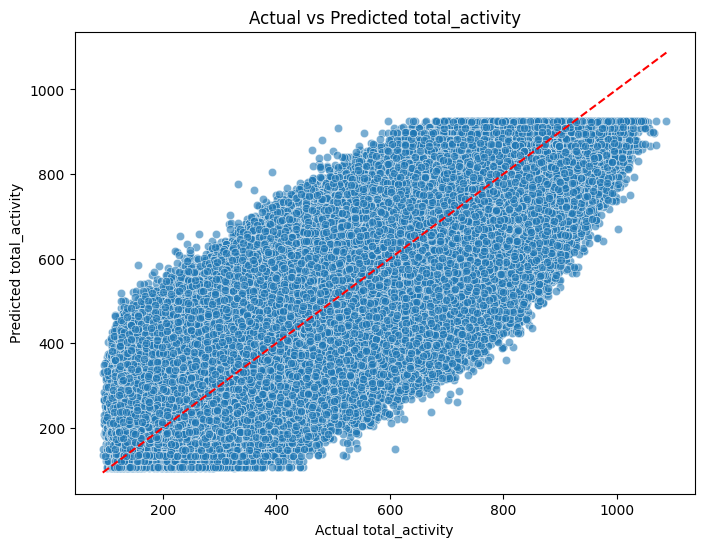

In [17]:
y_pred2 = model_subset.predict(X3_clean)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=y_pred2, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # perfect fit line
plt.xlabel('Actual total_activity')
plt.ylabel('Predicted total_activity')
plt.title('Actual vs Predicted total_activity')
plt.show()